In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_qc(csv_path="qc_inspection.csv", seed=200, verbose=False):
    """Automated quality-control decisions for machined parts — a FAIRNESS &
    EXPLAINABILITY lab (U20). An ML model decides pass/fail (here: predict `reject`).
    The 'protected groups' are the three SUPPLIERS (A/B/C) feeding the line.

    A real fairness trap is built in: supplier C's parts are machined on older tooling, so
    they carry slightly higher surface roughness *without* being truly defective more often.
    A naive model can learn to over-reject supplier C (a disparate false-reject rate) — the
    exact harm a fairness audit must catch and mitigate.

    Columns:
      dim_error_um, surface_ra_um, hardness_hv, roundness_um, threadfit_score, weight_g
                                  -> objective measurements
      supplier                    -> A / B / C   (protected attribute)
      machine_age_yrs             -> tooling age (proxy that correlates with supplier C)
      reject                      -> ground-truth scrap decision (target)
    """
    rng = np.random.default_rng(seed)
    N = 3000
    supplier = rng.choice(["A", "B", "C"], N, p=[0.4, 0.35, 0.25])

    # tooling age depends on supplier (C runs older machines) -> a proxy feature
    base_age = {"A": 3.0, "B": 5.0, "C": 9.0}
    machine_age = np.array([rng.normal(base_age[s], 1.5) for s in supplier]).clip(0.5, 15)

    dim_error = rng.normal(8, 3, N).clip(0, 25)            # microns from nominal
    hardness = rng.normal(220, 18, N).clip(160, 290)       # HV
    roundness = rng.normal(6, 2.2, N).clip(0.5, 18)        # microns
    threadfit = rng.normal(0.0, 1.0, N)                    # standardized score
    weight = rng.normal(250, 6, N).clip(225, 275)

    # surface roughness: driven by tooling age (so supplier C looks rougher) + noise
    surface_ra = (1.8 + 0.18 * machine_age + rng.normal(0, 0.5, N)).clip(0.5, 6.0)

    # TRUE reject depends ONLY on genuine quality drivers (NOT supplier, NOT mere roughness).
    # Made SHARP so the genuine signal is learnable -> the model catches real defects in every
    # supplier, and any over-rejection of C is then clearly attributable to label bias.
    drive = (0.42 * dim_error + 0.8 * np.maximum(roundness - 6, 0)
             + 1.6 * np.maximum(np.abs(threadfit) - 1.0, 0) + 0.05 * np.abs(hardness - 220))
    thr = np.quantile(drive, 0.80)                       # ~20% true reject rate
    p = 1 / (1 + np.exp(-2.0 * (drive - thr)))           # sharp -> learnable
    reject = (rng.random(N) < p).astype(int)

    # HISTORICAL LABEL BIAS: past inspectors over-scrapped rougher-looking supplier-C parts.
    # Some truly-GOOD C parts were recorded as rejects (false rejects baked into history).
    reject_recorded = reject.copy()
    good_C = (reject == 0) & (supplier == "C") & (surface_ra > 3.0)
    bias_flip = good_C & (rng.random(N) < 0.45)
    reject_recorded[bias_flip] = 1

    df = pd.DataFrame({
        "dim_error_um": dim_error.round(2), "surface_ra_um": surface_ra.round(2),
        "hardness_hv": hardness.round(0), "roundness_um": roundness.round(2),
        "threadfit_score": threadfit.round(3), "weight_g": weight.round(1),
        "machine_age_yrs": machine_age.round(1), "supplier": supplier,
        "reject_recorded": reject_recorded,   # biased historical label (train on this)
        "reject": reject,                      # fair ground truth (audit against this)
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("qc:", df.shape, "| true reject rate:", round(reject.mean(), 3))
        print("true reject rate BY supplier (should be ~equal — bias is in the FEATURES, not truth):")
        print(df.groupby("supplier")["reject"].mean().round(3).to_string())
        print("mean surface_ra BY supplier (the proxy that can mislead a model):")
        print(df.groupby("supplier")["surface_ra_um"].mean().round(2).to_string())
        print("RECORDED (biased) reject rate BY supplier (note C inflated):")
        print(df.groupby("supplier")["reject_recorded"].mean().round(3).to_string())
    return df

if not os.path.exists('qc_inspection.csv'):
    build_qc(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('qc_inspection.csv')
print('rows:', df.shape)
print('\nTRUE reject rate by supplier (fair ground truth — nearly equal):')
print(df.groupby('supplier')['reject'].mean().round(3).to_string())
print('\nRECORDED reject rate by supplier (biased history — C inflated):')
print(df.groupby('supplier')['reject_recorded'].mean().round(3).to_string())
df.head(3)


Generated dataset file.
rows: (3000, 10)

TRUE reject rate by supplier (fair ground truth — nearly equal):
supplier
A    0.219
B    0.213
C    0.233

RECORDED reject rate by supplier (biased history — C inflated):
supplier
A    0.219
B    0.213
C    0.505


,dim_error_um,surface_ra_um,hardness_hv,roundness_um,threadfit_score,weight_g,machine_age_yrs,supplier,reject_recorded,reject
0,4.73,2.33,227.0,12.33,1.010,248.4,2.0,B,1,1
1,11.63,2.76,215.0,4.54,0.755,240.0,4.3,B,0,0
2,6.88,1.92,221.0,7.58,-0.041,237.5,2.6,A,0,0


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. A NAIVE QC MODEL (trained on the historical reject_recorded)
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
feat = ['dim_error_um', 'surface_ra_um', 'hardness_hv', 'roundness_um',
        'threadfit_score', 'weight_g', 'machine_age_yrs', 'supplier']
num = [c for c in feat if c != 'supplier']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(), ['supplier'])])
X = df[feat]; y_train_label = df['reject_recorded']; y_true = df['reject']
Xtr, Xte, ytr, yte, gtr, gte, truetr, truete = train_test_split(
    X, y_train_label, df['supplier'], y_true, test_size=0.3, random_state=42, stratify=df['supplier'])
clf = Pipeline([('prep', pre), ('rf', RandomForestClassifier(n_estimators=300, random_state=0))]).fit(Xtr, ytr)
pred = clf.predict(Xte)
print('overall accuracy vs recorded labels:', round(accuracy_score(yte, pred), 3))
print('Looks fine overall — but overall metrics can hide per-group harm.')


overall accuracy vs recorded labels: 0.844
Looks fine overall — but overall metrics can hide per-group harm.


/tmp/ipykernel_4989/3917281739.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  report = audit.groupby('supplier').apply(group_metrics).round(3)


          reject_rate  false_reject_rate  recall
supplier                                        
A               0.198              0.047   0.670
B               0.152              0.054   0.607
C               0.477              0.355   0.882

Watch the false_reject_rate column: supplier C good parts get scrapped far more often.
Demographic-parity gap (reject-rate spread): 0.325
False-reject-rate gap across suppliers:      0.308


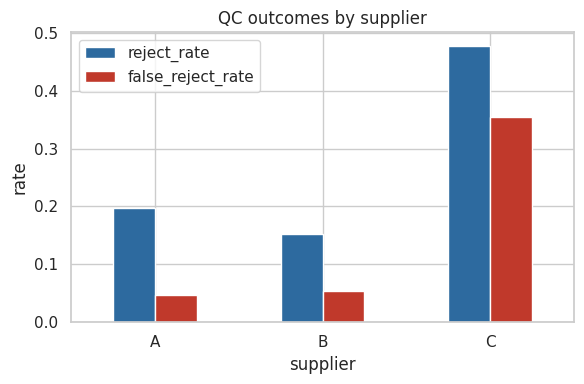

In [ ]:

# -----------------------------------------------------------
# 🔹 2A. GROUP METRICS (audit predictions against the FAIR ground truth)
# -----------------------------------------------------------
audit = pd.DataFrame({'supplier': gte.values, 'pred': pred, 'true': truete.values})
def group_metrics(g):
    sel = g['pred'].mean()                                  # selection (reject) rate
    good = g[g['true'] == 0]                                # truly-OK parts
    frr = good['pred'].mean() if len(good) else np.nan      # false-reject rate (FPR)
    bad = g[g['true'] == 1]
    tpr = bad['pred'].mean() if len(bad) else np.nan        # true defects caught (recall)
    return pd.Series({'reject_rate': sel, 'false_reject_rate': frr, 'recall': tpr})
report = audit.groupby('supplier').apply(group_metrics).round(3)
print(report.to_string())
print('\nWatch the false_reject_rate column: supplier C good parts get scrapped far more often.')


# -----------------------------------------------------------
# 🔹 2B. FAIRNESS GAPS
# -----------------------------------------------------------
dp_gap = report['reject_rate'].max() - report['reject_rate'].min()       # demographic parity gap
eo_gap = report['false_reject_rate'].max() - report['false_reject_rate'].min()  # equal-opportunity-ish
print(f'Demographic-parity gap (reject-rate spread): {dp_gap:.3f}')
print(f'False-reject-rate gap across suppliers:      {eo_gap:.3f}')
fig, ax = plt.subplots(figsize=(6, 4))
report[['reject_rate', 'false_reject_rate']].plot(kind='bar', ax=ax, color=['#2D6A9F', '#C0392B'])
ax.set_title('QC outcomes by supplier'); ax.set_ylabel('rate'); ax.set_xlabel('supplier')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [ ]:
# 1. Quantify the worst false-reject gap

# False Reject = predicted defective (1) when the true label is good (0)
false_reject = (
    (audit["pred"] == 1) &
    (audit["true"] == 0)
)

# False-reject rate for each supplier
fr_rate = false_reject.groupby(audit["supplier"]).mean()

print("False-Reject Rate by Supplier:")
print(fr_rate)

False-Reject Rate by Supplier:
supplier
A    0.035714
B    0.044304
C    0.272727
dtype: float64


To install a Python library, use the `!pip install` command followed by the package name. For example, to install `requests`:

In [ ]:
!pip install requests

After installation, you can import and use the library in your code.

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. THE PROXY: surface roughness tracks supplier, not true quality
# -----------------------------------------------------------
print('mean surface_ra by supplier:')
print(df.groupby('supplier')['surface_ra_um'].mean().round(2).to_string())
print('\ncorr(surface_ra, TRUE reject):', round(df['surface_ra_um'].corr(df['reject']), 3))
print('corr(surface_ra, RECORDED reject):', round(df['surface_ra_um'].corr(df['reject_recorded']), 3))
print('\nRoughness barely relates to TRUE defects, but strongly to the BIASED labels ->')
print('the model uses roughness as a proxy for supplier C and over-rejects it.')

mean surface_ra by supplier:
supplier
A    2.34
B    2.72
C    3.41

corr(surface_ra, TRUE reject): 0.043
corr(surface_ra, RECORDED reject): 0.225

Roughness barely relates to TRUE defects, but strongly to the BIASED labels ->
the model uses roughness as a proxy for supplier C and over-rejects it.


In [ ]:
# Create a binary indicator for Supplier C
supplier_c = (df["supplier"] == "C").astype(int)

# Correlation of machine_age_yrs with Supplier C
corr_supplier_c = df["machine_age_yrs"].corr(supplier_c)

# Correlation of machine_age_yrs with the true reject label
corr_true_reject = df["machine_age_yrs"].corr(df["reject"])

print(f"Correlation (machine_age_yrs, Supplier C): {corr_supplier_c:.3f}")
print(f"Correlation (machine_age_yrs, True Reject): {corr_true_reject:.3f}")

Correlation (machine_age_yrs, Supplier C): 0.781
Correlation (machine_age_yrs, True Reject): 0.011


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. PER-GROUP THRESHOLDS (post-processing)
# Pick each supplier's threshold so their reject rate matches the fleet target.
# -----------------------------------------------------------
proba_te = clf.predict_proba(Xte)[:, 1]
target = truete.mean()    # fair target reject rate (~true overall rate)
aud = pd.DataFrame({'supplier': gte.values, 'proba': proba_te, 'true': truete.values})
thresholds = {}
for s, g in aud.groupby('supplier'):
    thresholds[s] = np.quantile(g['proba'], 1 - target)   # reject the top-`target` fraction
aud['pred_fair'] = aud.apply(lambda r: int(r['proba'] >= thresholds[r['supplier']]), axis=1)
def frr(g): good = g[g['true'] == 0]; return good['pred_fair'].mean()
fair_report = aud.groupby('supplier').apply(lambda g: pd.Series({
    'reject_rate': g['pred_fair'].mean(), 'false_reject_rate': frr(g)})).round(3)
print('after per-group thresholds:'); print(fair_report.to_string())
print('\nfalse-reject-rate gap before vs after:',
      round(eo_gap, 3), '->', round(fair_report['false_reject_rate'].max() - fair_report['false_reject_rate'].min(), 3))


after per-group thresholds:
          reject_rate  false_reject_rate
supplier                                
A               0.217              0.069
B               0.218              0.112
C               0.218              0.101

false-reject-rate gap before vs after: 0.308 -> 0.043


/tmp/ipykernel_4989/1536379094.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fair_report = aud.groupby('supplier').apply(lambda g: pd.Series({


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Reweighting mitigation + re-audit

# Apply preprocessing to Xtr and Xte
Xtr_processed = pre.fit_transform(Xtr)
Xte_processed = pre.transform(Xte)

# Train a reweighted Random Forest
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    random_state=42
)

# Train the model
rf_balanced.fit(Xtr_processed, ytr)

# Predictions
y_pred_balanced = rf_balanced.predict(Xte_processed)

print("Accuracy (Balanced RF):",
      round(accuracy_score(yte, y_pred_balanced), 3))

# Re-audit the false-reject rate by supplier
audit = pd.DataFrame({'supplier': gte.values, 'pred': y_pred_balanced, 'true': truete.values})

# False Reject = predicted reject when actually good
false_reject = (
    (audit["pred"] == 1) &
    (audit["true"] == 0)
)

fr_rate = false_reject.groupby(audit["supplier"]).mean()

print("\nFalse-Reject Rate by Supplier:")
print(fr_rate)

gap = fr_rate.max() - fr_rate.min()

print(f"\nFalse-Reject Gap: {gap:.3f}")

Accuracy (Balanced RF): 0.843

False-Reject Rate by Supplier:
supplier
A    0.035714
B    0.041139
C    0.245455
dtype: float64

False-Reject Gap: 0.210


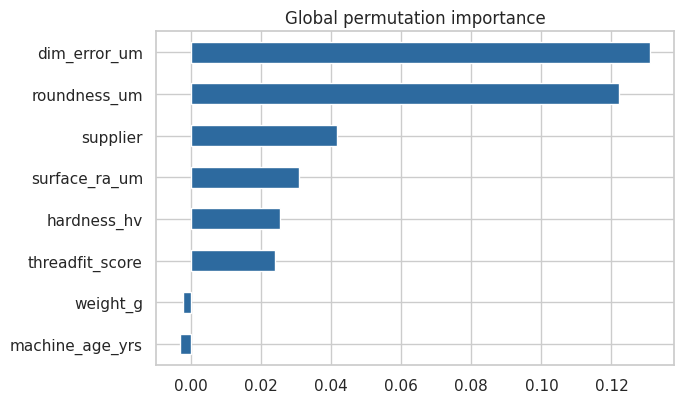

If surface_ra / machine_age rank high, the model leans on the biased proxy — a red flag.


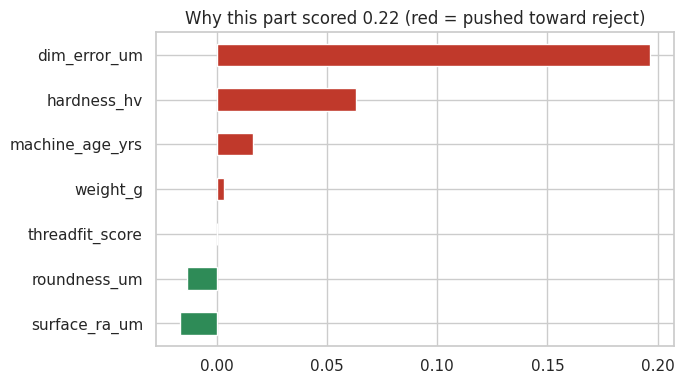

Local explanation: which measurements drove THIS part’s decision.


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. GLOBAL: PERMUTATION IMPORTANCE (which features drive rejects?)
# -----------------------------------------------------------
from sklearn.inspection import permutation_importance
imp = permutation_importance(clf, Xte, yte, n_repeats=8, random_state=0, scoring='roc_auc')
imp_s = pd.Series(imp.importances_mean, index=feat).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp_s.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Global permutation importance')
plt.tight_layout(); plt.show()
print('If surface_ra / machine_age rank high, the model leans on the biased proxy — a red flag.')


# -----------------------------------------------------------
# 🔹 5B. LOCAL: EXPLAIN ONE DECISION (a SHAP-style local contribution)
# Approximate each feature's push by perturbing it to the population median.
# -----------------------------------------------------------
row = Xte.iloc[[0]].copy()
base = clf.predict_proba(row)[0, 1]
med = df[num].median()
contrib = {}
for c in num:
    pert = row.copy(); pert[c] = med[c]
    contrib[c] = base - clf.predict_proba(pert)[0, 1]   # how much this feature pushed the score up
local = pd.Series(contrib).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#C0392B' if v > 0 else '#2E8B57' for v in local.values]
local.plot(kind='barh', color=colors, ax=ax)
ax.set_title(f'Why this part scored {base:.2f} (red = pushed toward reject)'); plt.tight_layout(); plt.show()
print('Local explanation: which measurements drove THIS part’s decision.')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Reweighting mitigation + re-audit

# Apply preprocessing to Xtr and Xte
Xtr_processed = pre.fit_transform(Xtr)
Xte_processed = pre.transform(Xte)

# Train a reweighted Random Forest
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    random_state=42
)

# Train the model
rf_balanced.fit(Xtr_processed, ytr)

# Predictions
y_pred_balanced = rf_balanced.predict(Xte_processed)

print("Accuracy (Balanced RF):",
      round(accuracy_score(yte, y_pred_balanced), 3))

# Re-audit the false-reject rate by supplier
audit = pd.DataFrame({'supplier': gte.values, 'pred': y_pred_balanced, 'true': truete.values})

# False Reject = predicted reject when actually good
false_reject = (
    (audit["pred"] == 1) &
    (audit["true"] == 0)
)

fr_rate = false_reject.groupby(audit["supplier"]).mean()

print("\nFalse-Reject Rate by Supplier:")
print(fr_rate)

gap = fr_rate.max() - fr_rate.min()

print(f"\nFalse-Reject Gap: {gap:.3f}")

Accuracy (Balanced RF): 0.843

False-Reject Rate by Supplier:
supplier
A    0.035714
B    0.041139
C    0.245455
dtype: float64

False-Reject Gap: 0.210
